In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

/bin/bash: /home/huuthanhvy.nguyen001/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
--2026-04-25 14:44:48--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz’

mito.npz            100%[===================>]  35.87M  81.3MB/s    in 0.4s    

2026-04-25 14:44:49 (81.3 MB/s) - ‘mito.npz’ saved [37610178/37610178]



In [10]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [11]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [14]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#images: Takes the image values and squeezes them between 0 and 1.
#masks: Converts the masks to true/false values (boolean) and 
##then converts them back to numbers (0 and 1)

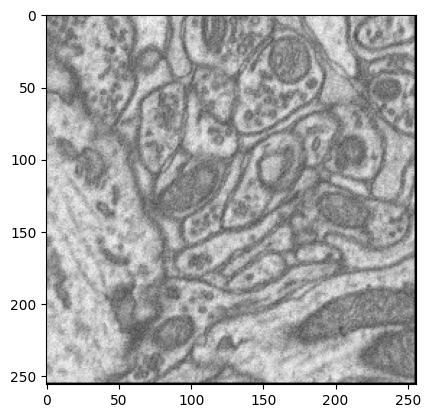

In [12]:
imshow(images[0], cmap='gray')

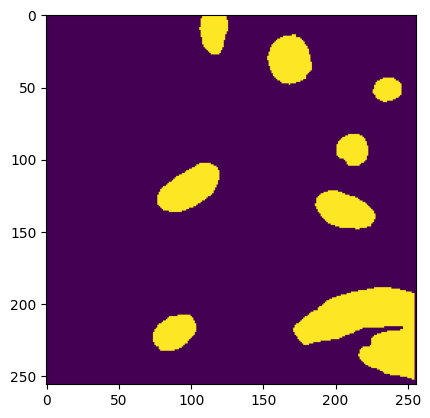

In [16]:
imshow(masks[0])

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [86]:
print("Total images:", len(images))
print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

Total images: 660
Training images: 462
Validation images: 99
Test images: 99


In [18]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

# First split:

# Takes all your images and masks
# Splits them into 2 groups:
# Training data (70%): used to teach the mode
# Temporary data (30%): will be split again

## Second split:

##Takes the temporary data (30%)
##Splits it equally in half (50/50):

##Validation data (15%): used to check if model is learning
##Test data (15%): used to test final performance

### Result:

### Training: 70% of data
### Validation: 15% of data
### Test: 15% of data

## 2. Make the Data Pytorch-ready! (10 points)

In [19]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [20]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [22]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#Creates random changes to training images:

#HorizontalFlip(p=0.5): flip left-right 50% of the time
#VerticalFlip(p=0.5): flip up-down 50% of the time
#RandomRotate90(p=0.5): rotate 90 degrees 50% of the time

## There are no changing for validation dataset.

In [29]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [30]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [31]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

In [27]:
#MitoDataset class:

#Takes images and masks
#Applies random changes (flip, rotate) to training data.
#Converts images/masks to correct format for the model.

In [ ]:
##DataLoader:

## Groups images into batches (16 images at a time)
## shuffle=True for training (mix up order to help learning)
## shuffle=False for validation/test (keep same order)
## num_workers=2: uses 2 computers to load data faster

In [32]:
### Final format:

#Images: (1, H, W) - 1 channel (grayscale), height, width
#Masks: (1, H, W) - same format
#Both converted to PyTorch tensors

## 3. Configure the Classifier! (30 points)

In [33]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [34]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [35]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [36]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [37]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4303, train_dice=0.6127 | val_loss=0.5174, val_dice=0.2139
Epoch 2/10 | train_loss=0.1731, train_dice=0.8335 | val_loss=0.1616, val_dice=0.7966
Epoch 3/10 | train_loss=0.1079, train_dice=0.8746 | val_loss=0.1955, val_dice=0.7359
Epoch 4/10 | train_loss=0.0884, train_dice=0.8899 | val_loss=0.2522, val_dice=0.6640
Epoch 5/10 | train_loss=0.0769, train_dice=0.9005 | val_loss=0.0765, val_dice=0.8943
Epoch 6/10 | train_loss=0.0727, train_dice=0.9038 | val_loss=0.0589, val_dice=0.9204
Epoch 7/10 | train_loss=0.0609, train_dice=0.9178 | val_loss=0.0546, val_dice=0.9282
Epoch 8/10 | train_loss=0.0550, train_dice=0.9248 | val_loss=0.0491, val_dice=0.9287
Epoch 9/10 | train_loss=0.0502, train_dice=0.9329 | val_loss=0.0455, val_dice=0.9376
Epoch 10/10 | train_loss=0.0495, train_dice=0.9336 | val_loss=0.0480, val_dice=0.9337
Best val dice: 0.9376234923090253


In [ ]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

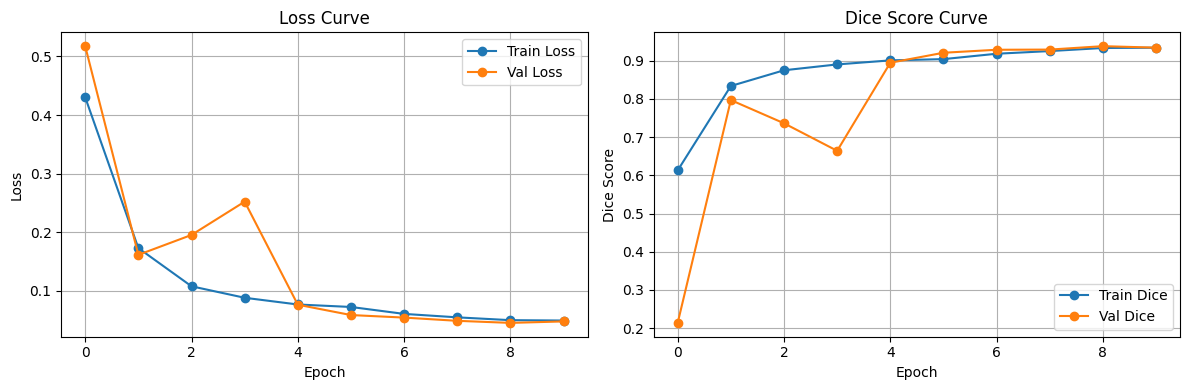

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

# Plot dice
ax2.plot(train_dices, label='Train Dice', marker='o')
ax2.plot(val_dices, label='Val Dice', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice Score Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [42]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

#The loss curve and dice score curve are good after epoch 4. 
#From epoch 0 to 4, both curves are very bouncy. 
#After epoch 4, the curves become smooth and stable, showing the model has learned well.

## 5. Testing the U-Net. (20 points)

In [43]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0465
Test dice: 0.9347


In [44]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

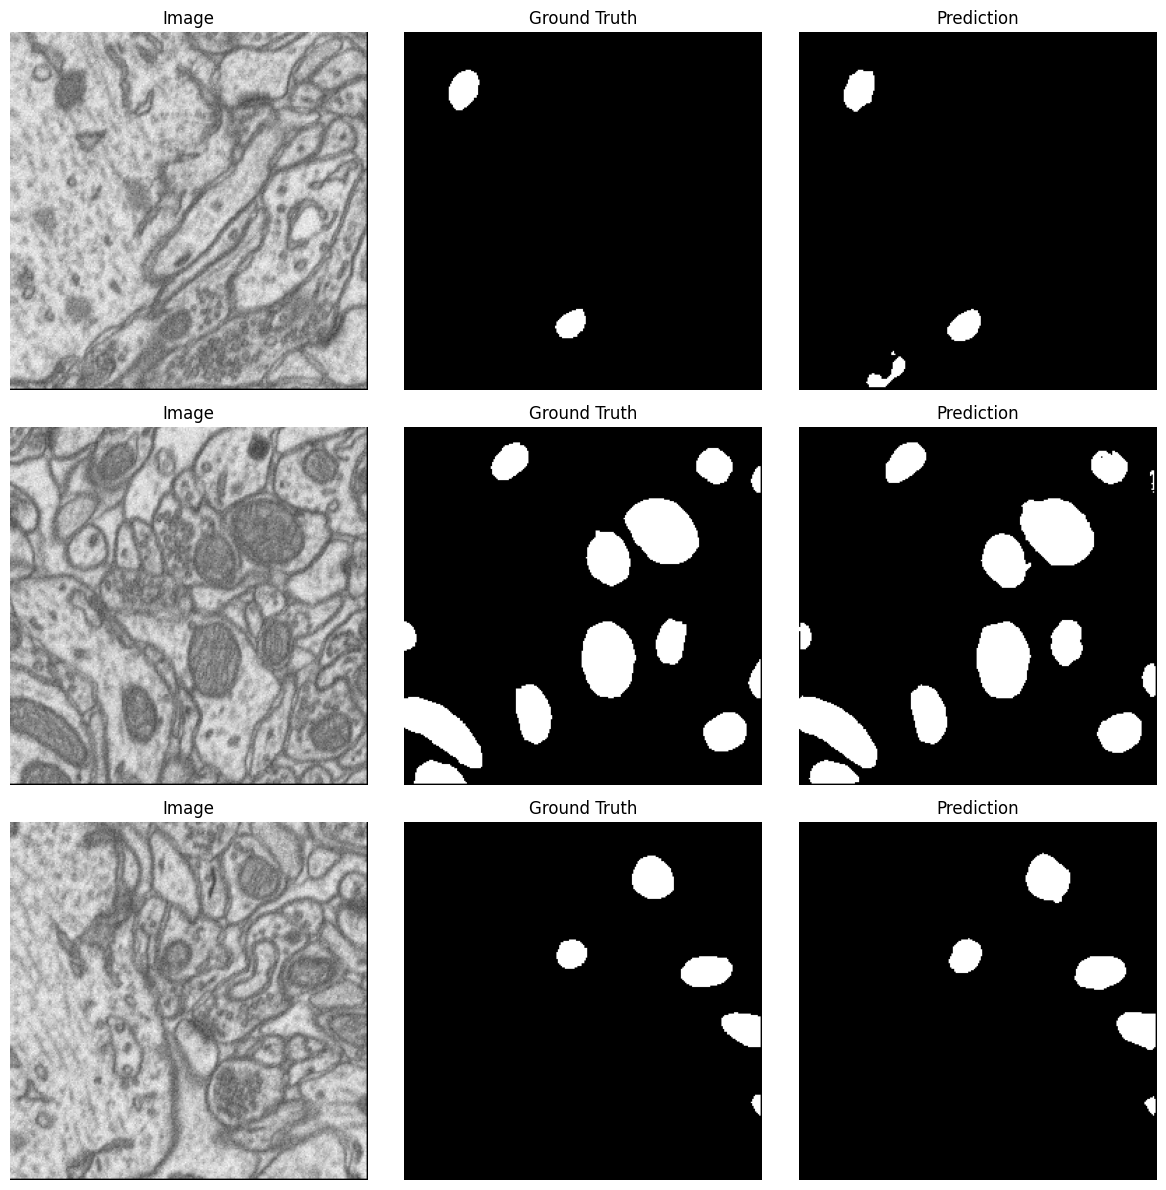

In [45]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [ ]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER

In [46]:
## Row 1 image: Tiny extra noise in prediction (small mistake)
## Row 2 image: Shapes and sizes match very well. Positions are correct. Only tiny differences in edges
## Row 3 image: All mitochondria detected correctly. Shape matches perfectly. Positions are accurate. Edges not perfectly smooth.

### The model works VERY WELL on this image too. Only row 1 image has a tiny extra noise.
### Perfect detection with only minor pixel-level imperfections at the edges.
### The predictions are nearly identical to ground truth.

## Bonus: Improve the results. (33 points)

In [ ]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!

In [56]:
import segmentation_models_pytorch as smp

In [78]:
model1 = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
).to(device)

In [79]:
optimizer = torch.optim.Adam(model1.parameters(), lr=1e-4)

num_epochs = 20
train_losses, val_losses = [], []
train_dices, val_dices = [], []
best_val_dice = 0.0

In [80]:
for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model1, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model1, val_loader, optimizer=None)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model1.state_dict(), "best_model1.pth")
    
    print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | val_loss={val_loss:.4f}, val_dice={val_dice:.4f}")

Epoch 1/20 | train_loss=0.6328, train_dice=0.2643 | val_loss=0.7400, val_dice=0.2122
Epoch 2/20 | train_loss=0.5465, train_dice=0.6684 | val_loss=0.5808, val_dice=0.5544
Epoch 3/20 | train_loss=0.4754, train_dice=0.8227 | val_loss=0.4406, val_dice=0.8686
Epoch 4/20 | train_loss=0.4160, train_dice=0.8786 | val_loss=0.3849, val_dice=0.9079
Epoch 5/20 | train_loss=0.3633, train_dice=0.9004 | val_loss=0.3387, val_dice=0.9252
Epoch 6/20 | train_loss=0.3171, train_dice=0.9169 | val_loss=0.2953, val_dice=0.9319
Epoch 7/20 | train_loss=0.2786, train_dice=0.9212 | val_loss=0.2585, val_dice=0.9152
Epoch 8/20 | train_loss=0.2445, train_dice=0.9265 | val_loss=0.2274, val_dice=0.9401
Epoch 9/20 | train_loss=0.2150, train_dice=0.9341 | val_loss=0.1977, val_dice=0.9431
Epoch 10/20 | train_loss=0.1884, train_dice=0.9400 | val_loss=0.1782, val_dice=0.9489
Epoch 11/20 | train_loss=0.1670, train_dice=0.9448 | val_loss=0.1549, val_dice=0.9514
Epoch 12/20 | train_loss=0.1492, train_dice=0.9470 | val_loss=0

In [81]:
# Load best model
model1.load_state_dict(torch.load("best_model1.pth"))
model1.eval()

# Get test loss and dice
test_loss, test_dice = run_epoch(model1, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.075
Test dice: 0.9607


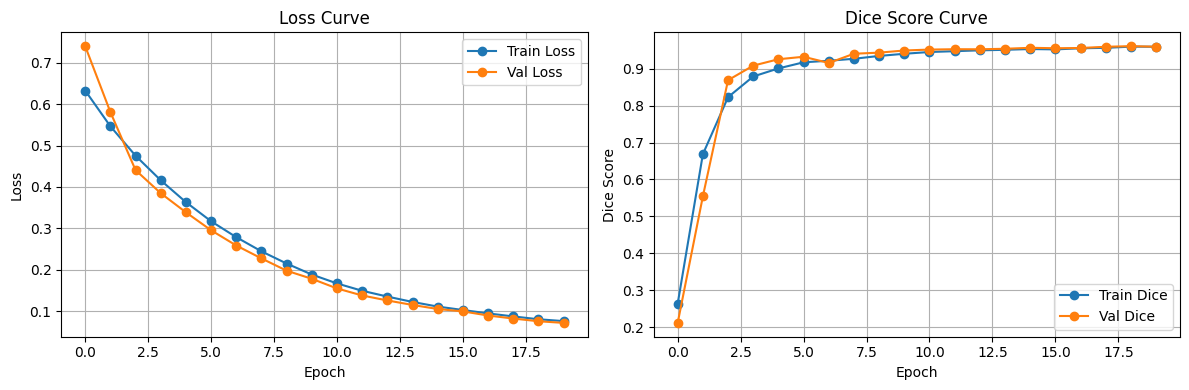

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(train_dices, label='Train Dice', marker='o')
ax2.plot(val_dices, label='Val Dice', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice Score Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

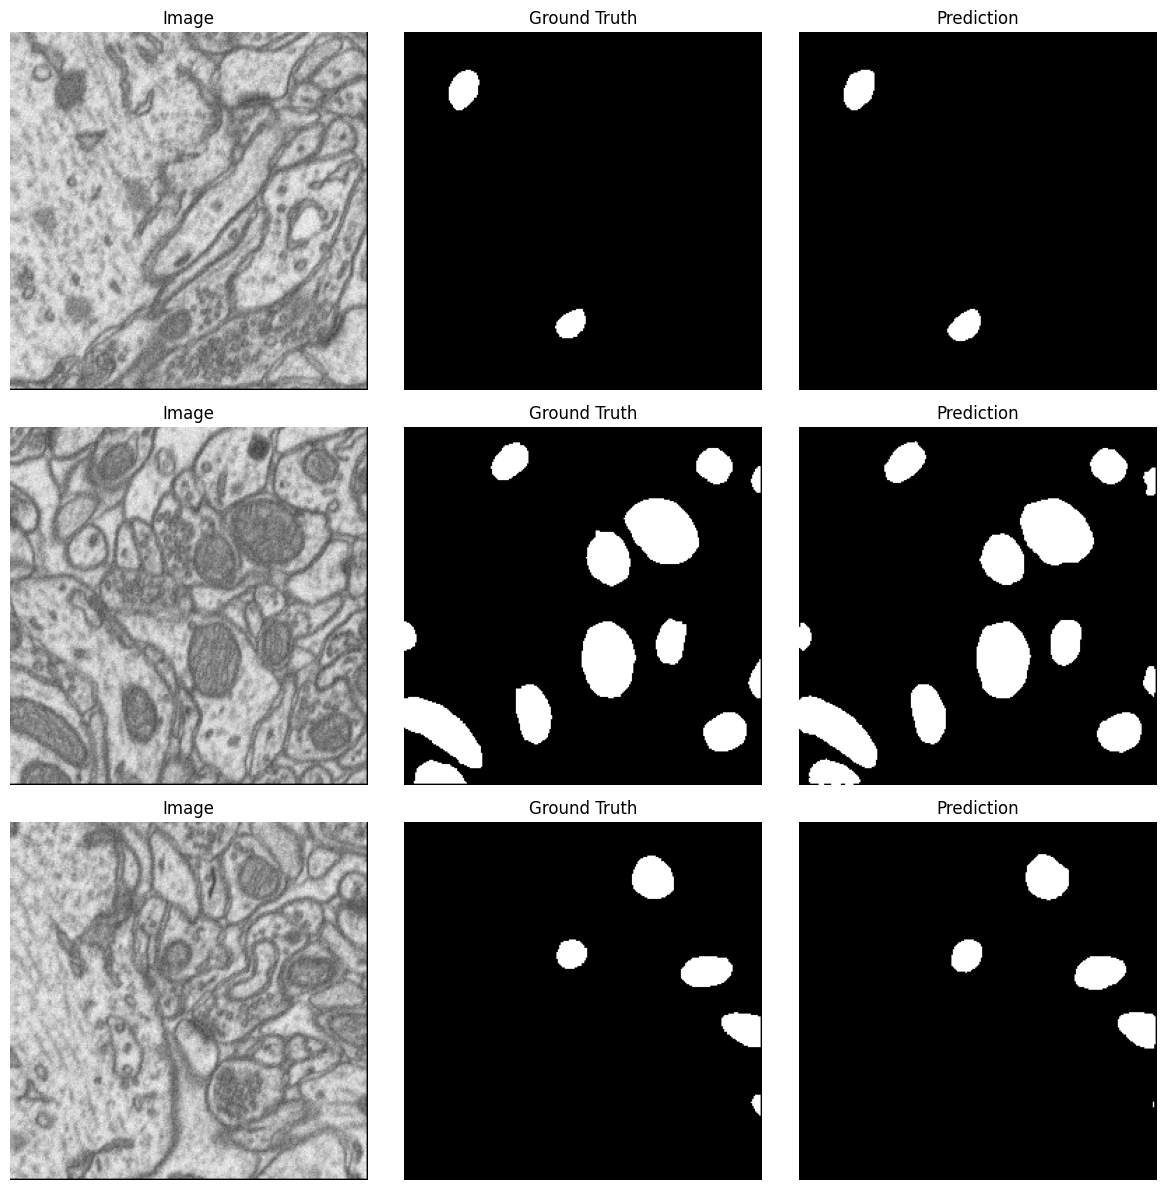

In [84]:
# Load best model
model1.load_state_dict(torch.load("best_model1.pth"))
model1.eval()

# Get batch from test set
images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)
masks_batch = masks_batch.to(device)

# Get predictions
with torch.no_grad():
    preds = model1(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

# Show results
n = 3
plt.figure(figsize=(12, 4 * n))
for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0].cpu().numpy(), cmap="gray")
    plt.title("Image")
    plt.axis("off")
    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0].cpu().numpy(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0].cpu().numpy(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [87]:
# I trained for 20 epochs instead of 10, giving the model more time to learn. 
# I also used resnet50 with imagenet pre-trained weights instead of resnet18, which provided better feature detection for edge boundaries.
# The dice score improved from 93.47% to 96.07% as resnet 50 learns better features with longer trainning.

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#